# Creating "Art" with CNNs

In our previous explorations of neural networks, we learned how to use gradients to trick a model (adversarial attacks) and how to visualize what specific neurons are looking for (activation maximization).

In this notebook, we are going to use those exact same tools—a frozen network and gradient optimization—but for a completely different purpose: Generative Art.

Instead of optimizing an image to break a classification boundary, we are going to optimize images to satisfy complex visual constraints. We will explore two of the most famous early techniques in neural generative art:

* Neural Style Transfer: Repainting a photograph so that it carries the exact textures, colors, and brush strokes of a famous painting.

* DeepDream: Letting the network "hallucinate" over an image, amplifying whatever patterns and objects it thinks it sees in the noise.

By the end of this notebook, you will understand how to build global objective functions that force a neural network to act not as a classifier, but as an art director.

# Style Transfer

Neural style transfer is a way to repaint one image using the style of a second image. 

You give it two references:

* A content image – the scene you care about (your photo of a building, a portrait, the clouds).

* A style image – the image whose colors, textures, and brushwork you want to borrow.

The algorithm then creates a third image that still shows the same scene as the content image, but looks as if it was painted in the style of the style image.

To achieve this, we are going to explore the internal activations of a pretrained classification model. Based on our exploration of these models, when we feed an image to such a model we have observed that early layers tend to focus on textures and patterns (the style), whereas the later layers create a more holistic representation of the image (the content).

Creating the resulting image, with the content from one input and style from another, is an iterative process that repeats the following steps starting from an initial canvas (commonly the generated image is set initially to a copy of the content image):

1. Run the generated image through the frozen network and compare how its internal activations differ from those of the content image and the style image.

1. Use gradients to slightly adjust the canvas pixels so that, in the network’s eyes, it looks more like the content in terms of structure and more like the style in terms of textures and colors.

Over time, this will create a new image that, according to the model:

- has the same high-level structure as the content image
- shares the same pattern statistics as the style image

The example below combines the content of a Labrador picture, with the style of a painting by Kandinsky.

![](notebook_images/style_transfer.png)

**Reference:**

Leon A. Gatys, Alexander S. Ecker, Matthias Bethge (2015), *A Neural Algorithm of Artistic Style* ([PDF](https://arxiv.org/abs/1508.06576))


In [1]:
import math
import os
from pathlib import Path

import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from PIL import Image
from torchvision import models, transforms
from torchvision.utils import save_image

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
OUTPUT_DIR = Path("output/style_transfer")
OUTPUT_DIR.mkdir(exist_ok=True)
print("device:", device)


device: cuda


## Aux functions to handle images

In [2]:
IMAGENET_MEAN = torch.tensor([0.485, 0.456, 0.406], device=device).view(1, 3, 1, 1)
IMAGENET_STD = torch.tensor([0.229, 0.224, 0.225], device=device).view(1, 3, 1, 1)


def load_image(path, max_size=512):
    img = Image.open(path).convert("RGB")
    w, h = img.size
    scale = max_size / max(w, h)
    if scale < 1:
        img = img.resize((int(w * scale), int(h * scale)), Image.LANCZOS)
    tensor = transforms.ToTensor()(img).unsqueeze(0).to(device)
    return tensor


def tensor_to_image(tensor):
    x = tensor.detach().clamp(0, 1).cpu().squeeze(0)
    return transforms.ToPILImage()(x)


def show(tensor, title=None, figsize=(8, 8)):
    img = tensor_to_image(tensor)
    plt.figure(figsize=figsize)
    plt.imshow(img)
    plt.axis("off")
    if title is not None:
        plt.title(title)
    plt.show()


def normalize(x):
    return (x - IMAGENET_MEAN) / IMAGENET_STD


def denormalize(x):
    return x * IMAGENET_STD + IMAGENET_MEAN


## Model

* Load the model with pretrained weights from ImageNet.

* Implement the feature extractor



In [3]:
vgg = models.vgg19(weights=models.VGG19_Weights.IMAGENET1K_V1).features.to(device).eval()
for p in vgg.parameters():
    p.requires_grad_(False)

layer_map = {
    "0": "conv1_1", "5": "conv2_1", "10": "conv3_1", "19": "conv4_1", "21": "conv4_2", "28": "conv5_1"
}


def extract_vgg_features(x, model, selected_layers=None):
    if selected_layers is None:
        selected_layers = set(layer_map.values())
    feats = {}
    for name, layer in model._modules.items():
        x = layer(x)
        if name in layer_map:
            label = layer_map[name]
            if label in selected_layers:
                feats[label] = x
    return feats

## The Loss function

In style transfer we want to create a new image based on two input images: the content and style images. This results in two goals:

- The new image has to preserve the overall appearance of the content image;
- The details in the new image should  be similar to the style image.

This leads to a loss function with two terms that can be written as:

$$L = \lambda_{content} L_{content} + \lambda_{style} L_{style}, $$

where $L_{content}$ and $L_{style}$ are the content and style loss functions, and $\lambda_{content}, \lambda_{style}$ are two parameters that let us adjust the relative strength of each loss

### The Content Loss
The content loss is the simpler of the two. To compute it, we pass both the generated image and the content image through our frozen network.

Because we want to match the overall layout and objects rather than the exact pixel colors, we pick a deeper layer in the network. The content loss is then calculated as the Mean Squared Error (MSE) between the feature maps of the generated image and the content image at this specific layer.

By minimizing this difference, we force the generated image to stimulate the deep structure detectors in the exact same way the original content image does.

Let $f(g)$ and $f(c)$ be the resulting activation maps when feeding the new and content images, respectively. Then the content loss can be written as:

$$ L_{content} = MSE(f(g), f(c))$$

### Style Loss

To focus on style we are going to use earlier layers in the model. However, if we simply used MSE on the raw feature maps of the early layers, the loss would penalize positional differences. It would force the generated image to copy where every brush stroke is in the style image, which ruins our content layout.

Instead, we change what we measure the MSE on:

* **From feature maps to relationships**: At several early and mid-level layers, for each image, we compute the dot products between all pairs of feature maps. This creates a **Gram matrix** for each layer.

* **Ignoring position**: The Gram matrix captures exactly how strongly different pattern detectors fire simultaneously across the entire image, completely ignoring *where* they fired. It acts as a structural fingerprint of the texture and color palette for that specific image.

* **Matching the fingerprints**: The style loss is the MSE between the Gram matrices of the generated image and the style image.

By minimizing the difference between these Gram matrices across multiple layers, we force the generated image to use the same textures and color relationships as the style image, without copying its layout.

Let $G(g)$ and $G(s)$ be the Gram matrices of the generated and style images for a specific layer. The style loss for that layer can be written as:

$$ L_{layer} = MSE(G(g), G(s)) $$

Because style is usually captured across multiple scales, the total style loss $L_{style}$ is typically the sum of these MSE losses across several different early and mid-level layers.

$$ L_{style} = \sum_{i \in layers} L_{i}$$

In [4]:
def gram_matrix(feat):
    b, c, h, w = feat.shape
    f = feat.view(b, c, h * w)
    g = torch.bmm(f, f.transpose(1, 2)) # bmm -> batch matrix multiplication
    return g / (c * h * w)


In [5]:
def style_transfer(
    content_img,
    style_img,
    steps=300,
    style_weight=1e6,
    content_weight=1.0,
    tv_weight=1e-5,
    lr=0.03,
    style_layers=("conv1_1", "conv2_1", "conv3_1", "conv4_1", "conv5_1"),
    content_layers=("conv4_2",),
):
    selected = set(style_layers) | set(content_layers)
    content_feats = extract_vgg_features(normalize(content_img), vgg, content_layers)
    style_feats = extract_vgg_features(normalize(style_img), vgg, style_layers)
    style_targets = {k: gram_matrix(style_feats[k]).detach() for k in style_layers}
    content_targets = {k: content_feats[k].detach() for k in content_layers}

    generated = content_img.clone().requires_grad_(True)
    optimizer = torch.optim.Adam([generated], lr=lr)

    history = []
    for step in range(steps):
        optimizer.zero_grad()
        gen_feats = extract_vgg_features(normalize(generated), vgg, selected)

        s_loss = 0.0
        for layer in style_layers:
            s_loss = s_loss + F.mse_loss(gram_matrix(gen_feats[layer]), style_targets[layer])

        c_loss = 0.0
        for layer in content_layers:
            c_loss = c_loss + F.mse_loss(gen_feats[layer], content_targets[layer])

        tv_loss = (
            torch.mean(torch.abs(generated[:, :, :, :-1] - generated[:, :, :, 1:]))
            + torch.mean(torch.abs(generated[:, :, :-1, :] - generated[:, :, 1:, :]))
        )

        loss = style_weight * s_loss + content_weight * c_loss + tv_weight * tv_loss
        loss.backward()
        optimizer.step()

        with torch.no_grad():
            generated.clamp_(0, 1)

        if step % 50 == 0 or step == steps - 1:
            history.append((step, float(s_loss.detach().cpu()), float(c_loss.detach().cpu()), float(tv_loss.detach().cpu())))
            print(f"step {step:04d} | style {history[-1][1]:.6f} | content {history[-1][2]:.6f} | tv {history[-1][3]:.6f}")

    return generated.detach(), history


All parameters are based on original paper, including the layer selection of the style and content layers to use in the loss function.

step 0000 | style 0.001172 | content 0.000000 | tv 0.079155
step 0050 | style 0.000015 | content 12.401353 | tv 0.190852
step 0100 | style 0.000008 | content 10.289302 | tv 0.192342
step 0150 | style 0.000006 | content 9.380268 | tv 0.194868
step 0200 | style 0.000005 | content 8.831692 | tv 0.197357
step 0250 | style 0.000005 | content 8.407775 | tv 0.199614
step 0299 | style 0.000004 | content 8.123768 | tv 0.201733


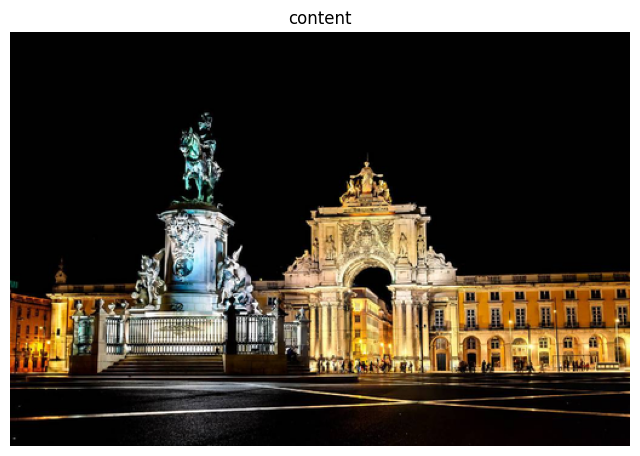

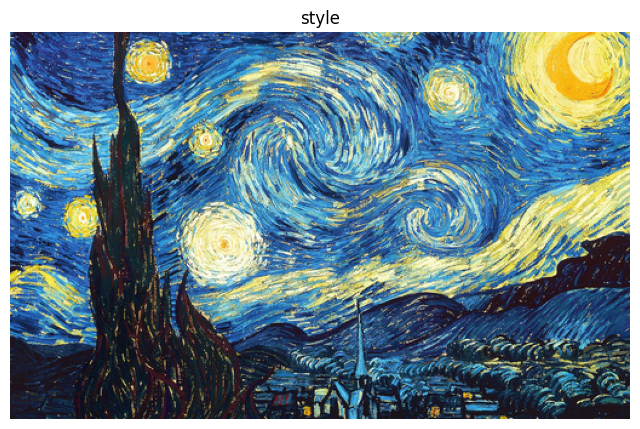

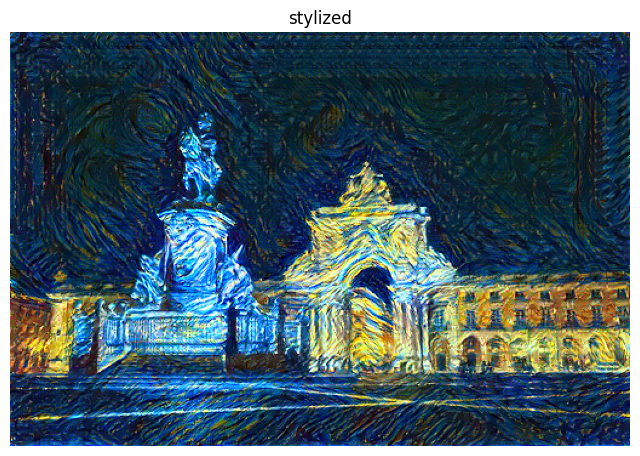

In [6]:
# Set your own paths here
CONTENT_PATH = "notebook_images/content.jpg"
STYLE_PATH = "notebook_images/style.jpg"

# Example usage after you place images in the notebook folder:
content = load_image(CONTENT_PATH, max_size=512)
style = load_image(STYLE_PATH, max_size=512)


result, hist = style_transfer(content, style, 
                        steps=300,
                        style_weight=1e6,
                        content_weight=1.0,
                        tv_weight=1e-5,
                        lr=0.03,
                        style_layers=("conv1_1", "conv2_1", "conv3_1", "conv4_1", "conv5_1"),
                        content_layers=("conv4_2",))


show(content, "content")
show(style, "style")
show(result, "stylized")
save_image(result.cpu(), OUTPUT_DIR / "stylized.png")


# DeepDream

DeepDream was originally developed in 2015 by Google engineer Alexander Mordvintsev. In a famous Google Research blog post titled "Inceptionism: Going Deeper into Neural Networks," Mordvintsev and his colleagues demonstrated that the same networks trained to classify images could be run in reverse to generate surreal, dream-like landscapes.

DeepDream uses exactly the same machinery as Neural Style Transfer: we freeze a pretrained classification network, we pass an image through it, and we use gradients to slowly update the pixels of the image.

However, instead of trying to match a specific content layout or the style of another painting, DeepDream asks the network to simply turn up the volume on whatever it already sees.

**Algorithmic Pareidolia**

Pareidolia is the human tendency to see faces or familiar shapes in random patterns, like clouds or wood grain. DeepDream does exactly this, but using the "brain" of a Convolutional Neural Network.

When we pass an image through the network, certain pattern detectors (neurons) will inevitably fire a little bit, even if the image is just random noise or a plain sky. The network might look at a slightly darker patch of cloud and think, "That edge looks 2% like the ear of a dog."

In DeepDream, we take those natural, accidental activations and maximize them.

1. We choose a specific layer in the network.

1. We feed our image in and look at the feature maps at that layer.

1. Our loss function is simply the sum (or average) of those activations. We don't compare it to anything; we just want the activations to be as large as possible.

1. We use gradient ascent to change the pixels of the image to make those neurons fire even harder.

In the cloud example, the network amplifies that 2% dog ear into a 10% dog ear. We feed the image back in, the network recognizes the ear even more strongly, and amplifies it again. A feedback loop begins. Eventually, a fully formed, hallucinatory dog face emerges from the cloud.

The Role of Layers
Just like in Style Transfer, the layer we choose determines what kind of shapes emerge:

* Early layers act as edge and texture detectors. Dreaming on these layers produces beautiful, intricate geometric patterns, swirling lines, and vivid colors.

* Deep layers have learned to identify complex object parts (because the network was trained on ImageNet, which is full of animals, cars, and buildings). Dreaming on deep layers produces surreal collages of eyes, faces, dog snouts, and architectural arches.

By combining this maximization process with techniques like octaves (scaling the image up repeatedly to build patterns at multiple sizes) and spatial masking, we can turn a photograph into a controlled surrealist landscape.

**Reference:**

Alexander Mordvintsev, Software Engineer, Christopher Olah, Software Engineering Intern and Mike Tyka,(2015), *Inceptionism: Going Deeper into Neural Networks* ([WEB](https://research.google/blog/inceptionism-going-deeper-into-neural-networks/))



In [7]:
class DeepDream(nn.Module):
    def __init__(self, model, layer_name):
        super().__init__()
        self.model = model
        self.layer_name = layer_name
        self.activations = None
        self.hook = None
        self._register_hook()

    def _register_hook(self):
        for name, layer in self.model._modules.items():
            if name == self.layer_name:
                self.hook = layer.register_forward_hook(self._hook_fn)
                return
        raise ValueError(f"Layer {self.layer_name} not found")

    def _hook_fn(self, module, inputs, output):
        self.activations = output

    def forward(self, x):
        self.activations = None
        _ = self.model(normalize(x))
        return self.activations


def gaussian_blur(x, kernel_size=3, sigma=0.5):
    if kernel_size <= 1:
        return x
    radius = kernel_size // 2
    coords = torch.arange(-radius, radius + 1, device=x.device, dtype=x.dtype)
    g = torch.exp(-(coords ** 2) / (2 * sigma ** 2))
    g = g / g.sum()
    kernel2d = torch.outer(g, g).view(1, 1, kernel_size, kernel_size)
    kernel2d = kernel2d.repeat(x.shape[1], 1, 1, 1)
    return F.conv2d(x, kernel2d, padding=radius, groups=x.shape[1])






In [ ]:
def build_dream_mask(img, blur_kernel=9, blur_sigma=2.0, brightness_pow=1.5, contrast_weight=0.7):
    gray = 0.2989 * img[:, 0:1] + 0.5870 * img[:, 1:2] + 0.1140 * img[:, 2:3]

    smooth = gaussian_blur(gray, kernel_size=blur_kernel, sigma=blur_sigma)
    local_contrast = (gray - smooth).abs()

    brightness = gray.pow(brightness_pow)
    mask = brightness + contrast_weight * local_contrast

    mask = mask - mask.amin(dim=(2, 3), keepdim=True)
    mask = mask / (mask.amax(dim=(2, 3), keepdim=True) + 1e-8)
    mask = 0.15 + 0.85 * mask
    return mask


def deep_dream(
    base_img,
    layer_name="19",
    iterations=32,
    lr=0.01,
    num_octaves=3,
    octave_scale=1.4,
    tv_weight=1.2e-5,
    jitter=6,
    blend=0.06,
    dream_strength=1.45,
    mask_strength=1.0,
):
    dreamer = DeepDream(vgg, layer_name)

    octaves = [base_img]
    for _ in range(1, num_octaves):
        h, w = octaves[-1].shape[-2:]
        smaller = F.interpolate(
            octaves[-1],
            size=(max(32, int(h / octave_scale)), max(32, int(w / octave_scale))),
            mode="bilinear",
            align_corners=False,
        )
        octaves.append(smaller)
    octaves = octaves[::-1]

    detail = torch.zeros_like(octaves[0])
    dreamed = None

    for octave_idx, octave_base in enumerate(octaves):
        if octave_idx > 0:
            detail = F.interpolate(detail, size=octave_base.shape[-2:], mode="bilinear", align_corners=False)

        dreamed = (octave_base + detail).clamp(0, 1)
        octave_original = octave_base.clone()
        mask = build_dream_mask(octave_original)
        mask = mask.pow(mask_strength)

        for i in range(iterations):
            ox = torch.randint(-jitter, jitter + 1, (1,)).item()
            oy = torch.randint(-jitter, jitter + 1, (1,)).item()

            shifted = torch.roll(dreamed, shifts=(ox, oy), dims=(2, 3)).detach().requires_grad_(True)
            act = dreamer(shifted)

            # We can also play with the objective functions.
            #objective = act.pow(2).mean()
            objective = act.abs().mean()

            tv_loss = (
                torch.mean(torch.abs(shifted[:, :, :, :-1] - shifted[:, :, :, 1:])) +
                torch.mean(torch.abs(shifted[:, :, :-1, :] - shifted[:, :, 1:, :]))
            )
            loss = objective - tv_weight * tv_loss
            loss.backward()

            grad = shifted.grad / (shifted.grad.abs().mean() + 1e-8)
            grad = grad * mask

            updated = shifted + dream_strength * lr * grad
            updated = torch.roll(updated.detach(), shifts=(-ox, -oy), dims=(2, 3)).clamp(0, 1)

            dreamed = (1 - blend) * updated + blend * octave_original
            dreamed = dreamed.clamp(0, 1)

            if i % 8 == 0 and i > 0:
                dreamed = gaussian_blur(dreamed, kernel_size=3, sigma=0.4).clamp(0, 1)

        detail = dreamed - octave_base

    if dreamer.hook is not None:
        dreamer.hook.remove()

    return dreamed.detach()

Some layers to investigate:

19: Conv2d(256 → 512) (often called conv4_1)

21: Conv2d(512 → 512) (conv4_2)

23: Conv2d(512 → 512) (conv4_3)

25: Conv2d(512 → 512) (conv4_4)

28: Conv2d(512 → 512) (conv5_1)

30: Conv2d(512 → 512) (conv5_2)

32: Conv2d(512 → 512) (conv5_3)

34: Conv2d(512 → 512) (conv5_4)

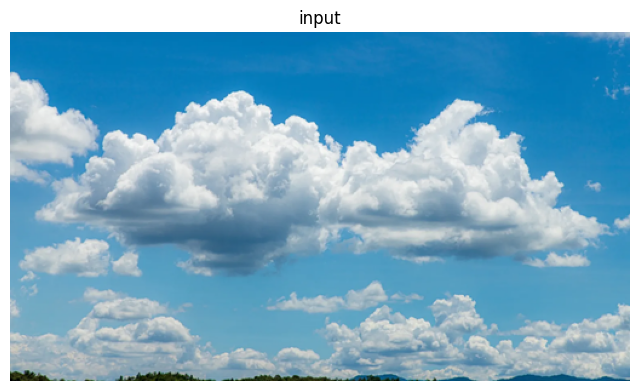

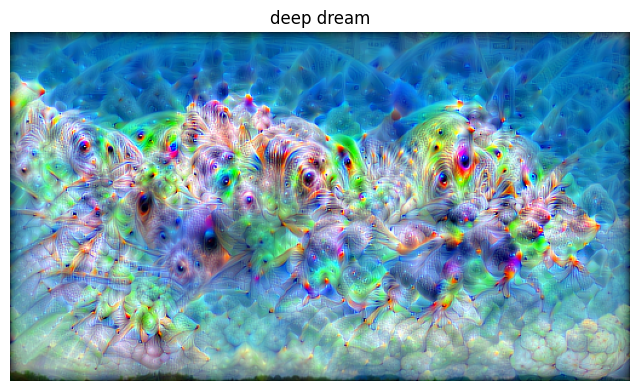

In [9]:
# Example usage after you place an image in the notebook folder:
image = 'notebook_images/clouds.webp'

dream_input = load_image(image, max_size=512)
#dreamed = deep_dream(dream_input, layer_name="28", iterations=60, num_octaves=4)

dreamed = deep_dream(
    dream_input,
    layer_name="34",
    iterations=50,
    lr=0.010,
    num_octaves=8,
    octave_scale=1.3,
    tv_weight=1.0e-4,
    jitter=8,
    blend=0.001,
    dream_strength=2.5,
    mask_strength=2,
)

show(dream_input, "input")
show(dreamed, "deep dream")
save_image(dreamed.cpu(), OUTPUT_DIR / "deepdream.png")


> **Sidebar: two ways to "hack" into a PyTorch model**

In this notebook, we used two completely different programming techniques to extract the intermediate feature maps from our VGG-19 network. This is intentional; both are standard PyTorch patterns used for different scenarios.

1. Sequential Unrolling (Used in Style Transfer)
For Style Transfer, we need to extract features from six different layers at once (five for style, one for content). Because the feature extractor of VGG-19 is essentially a straight line of layers (nn.Sequential), we can simply use a for loop to pass the image through the network step-by-step, saving the outputs of the layers we care about and continuing to the next.

2. Forward Hooks (Used in DeepDream)
For DeepDream, we usually only care about maximizing one specific layer at a time. Furthermore, we want a method that works on any architecture, including complex networks with branching paths (like ResNets) where a simple for loop would fail. To do this, we use PyTorch's official "wiretap" mechanism: the Forward Hook.

Looking at the DeepDream class, we can see exactly how this works:

1. We write a class that encapsulates the pretrained model.

1. We register a hook for our target layer. This is basically asking PyTorch to call a specific custom function the exact moment that layer finishes its computation.

1. Inside that custom function, we simply take the output of the layer and stash it in an instance variable (self.activations).

1- Finally, in our forward function, we feed the input image to the model. Instead of returning the final output of the model (which we don't care about), we return our stashed variable.

How Autograd handles this: Even though we intercept the middle of the network and discard the final classification output, PyTorch dynamically builds a computation graph connecting the input image directly to our stashed tensor. When we calculate the mean of that tensor and call .backward(), the autograd engine simply traverses this exact path backward, tracing the gradients from that specific hidden layer all the way down to the input pixels.